In [ ]:

from google.colab import drive
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm
from peft import LoraConfig, get_peft_model
import numpy as np
from sklearn.metrics import matthews_corrcoef, classification_report
import matplotlib.pyplot as plt
import json
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, classification_report

drive.mount('/content/drive')

os.makedirs('/content/drive/MyDrive/kvasir_lora_checkpoints', exist_ok=True)
os.makedirs('/content/drive/MyDrive/medical_image_datasets', exist_ok=True)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


In [ ]:

class GITransform:
    def __init__(self, is_training=True, img_size=224):
        self.is_training = is_training
        self.img_size = img_size

        self.train_transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                 saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        self.val_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

    def __call__(self, img):
        if self.is_training:
            return self.train_transform(img)
        else:
            return self.val_transform(img)

def prepare_datasets(data_path):
    """
    Prepare training and validation datasets
    Assumes directory structure:
    data_path/
        train/
            class1/
            class2/
        val/
            class1/
            class2/
    """
    train_transform = GITransform(is_training=True)
    val_transform = GITransform(is_training=False)

    train_dataset = ImageFolder(
        root=os.path.join(data_path, 'train'),
        transform=train_transform
    )

    val_dataset = ImageFolder(
        root=os.path.join(data_path, 'val'),
        transform=val_transform
    )

    return train_dataset, val_dataset, train_dataset.classes


In [ ]:

def setup_model(num_classes, lora_r=16, lora_alpha=32, lora_dropout=0.1):
    """Setup ConvNeXt-V2 with LoRA"""

    model = timm.create_model('convnextv2_base',
                            pretrained=True,
                            num_classes=num_classes)

    lora_config = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        target_modules=["qkv", "fc1", "fc2"],
        lora_dropout=lora_dropout,
        bias="none",
    )


    model = get_peft_model(model, lora_config)

    model.print_trainable_parameters()

    return model

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



In [ ]:
class GITrainer:
    def __init__(self, model, train_loader, val_loader, test_loader, optimizer, scheduler,
                 device, checkpoint_dir, class_names):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.checkpoint_dir = checkpoint_dir
        self.class_names = class_names

        self.criterion = nn.CrossEntropyLoss()

        self.epoch = 0
        self.global_step = 0
        self.best_accuracy = 0.0
        self.best_mcc = 0.0
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

    def save_checkpoint(self, is_best=False):
        """Save checkpoint that can resume training exactly"""
        checkpoint = {
            'epoch': self.epoch,
            'global_step': self.global_step,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict() if self.scheduler else None,
            'best_accuracy': self.best_accuracy,
            'best_mcc': self.best_mcc,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_accuracies': self.train_accuracies,
            'val_accuracies': self.val_accuracies,
            'class_names': self.class_names
        }

        latest_path = os.path.join(self.checkpoint_dir, 'latest_checkpoint.pth')
        torch.save(checkpoint, latest_path)

        if is_best:
            best_path = os.path.join(self.checkpoint_dir, 'best_checkpoint.pth')
            torch.save(checkpoint, best_path)

        print(f"💾 Checkpoint saved - Epoch {self.epoch}, Global Step {self.global_step}")

    def load_checkpoint(self):
        """Load checkpoint to resume training - FIXED VERSION"""
        checkpoint_path = os.path.join(self.checkpoint_dir, 'latest_checkpoint.pth')
        if os.path.exists(checkpoint_path):
            try:
                print("🔄 Loading checkpoint...")
                checkpoint = torch.load(checkpoint_path, map_location=self.device)


                self.model.load_state_dict(checkpoint['model_state_dict'])


                self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

                if self.scheduler and checkpoint['scheduler_state_dict']:
                    self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])


                self.epoch = checkpoint['epoch']
                self.global_step = checkpoint['global_step']
                self.best_accuracy = checkpoint['best_accuracy']
                self.best_mcc = checkpoint['best_mcc']
                self.train_losses = checkpoint['train_losses']
                self.val_losses = checkpoint['val_losses']
                self.train_accuracies = checkpoint['train_accuracies']
                self.val_accuracies = checkpoint['val_accuracies']

                print(f" Successfully loaded checkpoint:")
                print(f" Epoch: {self.epoch}")
                print(f" Global Step: {self.global_step}")
                print(f" Best Val Accuracy: {self.best_accuracy/100:.4f}")
                print(f" Training History: {len(self.train_losses)} epochs")
                return True

            except Exception as e:
                print(f" Error loading checkpoint: {e}")
                print(" Starting from scratch...")
                return False
        else:
            print("No checkpoint found - starting from scratch")
            return False

    def calculate_accuracy(self, loader, is_training=True):
        """Calculate accuracy and loss for train or validation"""
        if is_training:
            self.model.train()
        else:
            self.model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.set_grad_enabled(is_training):
            for images, targets in loader:
                images, targets = images.to(self.device), targets.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, targets)
                running_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()

        accuracy = 100 * correct / total
        avg_loss = running_loss / len(loader)

        return avg_loss, accuracy

    def train_epoch(self):
        """Train one epoch with checkpoint every 25 batches"""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        progress_bar = tqdm(self.train_loader, desc=f'Epoch {self.epoch+1}')

        for batch_idx, (images, targets) in enumerate(progress_bar):
            images, targets = images.to(self.device), targets.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, targets)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            self.global_step += 1


            batch_accuracy = 100 * (predicted == targets).sum().item() / targets.size(0)
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{batch_accuracy:.2f}%'
            })

            if (batch_idx + 1) % 25 == 0:
                self.save_checkpoint()

        epoch_loss = running_loss / len(self.train_loader)
        epoch_accuracy = 100 * correct / total

        return epoch_loss, epoch_accuracy

    def train(self, num_epochs, resume=True):
        """Main training loop - FIXED RESUME LOGIC"""
        start_epoch = 0


        if resume:
            if self.load_checkpoint():
                start_epoch = self.epoch + 1
                print(f" Resuming from epoch {start_epoch}")
            else:
                print(" Starting training from scratch")
                start_epoch = 0

        for epoch in range(start_epoch, num_epochs):
            self.epoch = epoch
            print(f"\n Epoch {epoch+1}/{num_epochs}")


            train_loss, train_accuracy = self.train_epoch()
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_accuracy)


            val_loss, val_accuracy = self.calculate_accuracy(self.val_loader, is_training=False)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_accuracy)


            print(f"Epoch Summary - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy/100:.4f}")
            print(f"Epoch Summary - Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy/100:.4f}")

            is_best = val_accuracy > self.best_accuracy
            if is_best:
                self.best_accuracy = val_accuracy
                print(f"Best Validation Accuracy: {self.best_accuracy/100:.4f}")
            else:
                print(f" Best Validation Accuracy: {self.best_accuracy/100:.4f}")

            if self.scheduler:
                self.scheduler.step()

            self.save_checkpoint(is_best=is_best)



In [ ]:

def main_training_script():

    config = {
        'data_path': '/content/drive/MyDrive/medical_image_datasets/kvasir-capsule',  # Update this path
        'batch_size': 64,
        'num_epochs': 10,
        'learning_rate': 1e-4,
        'lora_r': 16,
        'lora_alpha': 32,
        'img_size': 224,
        'checkpoint_dir': '/content/drive/MyDrive/kvasir_lora_checkpoints'
    }


    train_dataset, val_dataset, class_names = prepare_datasets(config['data_path'])


    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'],
                             shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'],
                           shuffle=False, num_workers=2)


    test_loader = val_loader

    print(f"Training samples: {len(train_dataset)}")
    print(f" Validation samples: {len(val_dataset)}")
    print(f" Number of Classes: {len(class_names)}")
    print(f" Classes: {class_names}")


    model = setup_model(num_classes=len(class_names),
                       lora_r=config['lora_r'],
                       lora_alpha=config['lora_alpha'])
    model = model.to(device)


    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                          T_max=config['num_epochs'])


    trainer = GITrainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        checkpoint_dir=config['checkpoint_dir'],
        class_names=class_names
    )


    trainer.train(num_epochs=config['num_epochs'], resume=True)

    return trainer


trainer = main_training_script()

After the 9th epoch there was slight change in the optimizer by adding a wt decay of ***0.01***

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score

def simple_evaluation():

    checkpoint_path = '/content/drive/MyDrive/kvasir_lora_checkpoints/best_checkpoint.pth'

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model = setup_model(num_classes=len(checkpoint['class_names']))
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()


    test_path = "/content/drive/MyDrive/medical_image_datasets/kvasir-capsule/test"
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_dataset = ImageFolder(root=test_path, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    print(f" Test samples: {len(test_dataset)}")
    print(f" Number of classes: {len(test_dataset.classes)}")

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())


    accuracy = accuracy_score(all_targets, all_preds)
    mcc = matthews_corrcoef(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    precision = precision_score(all_targets, all_preds, average='weighted')
    recall = recall_score(all_targets, all_preds, average='weighted')


  ")
    print("=" * 50)
    print(f" Best Validation Accuracy (during training): {checkpoint['best_accuracy']/100:.4f}")
    print(f" Test Accuracy:                            {accuracy:.4f}")
    print(f" Generalization Gap:                       {checkpoint['best_accuracy']/100 - accuracy:.4f}")
    print(f" Overall F1-Score:                         {f1:.4f}")
    print(f" Matthews Correlation Coefficient:         {mcc:.4f}")
    print(f" Precision:                                {precision:.4f}")
    print(f" Recall:                                   {recall:.4f}")
    print(f" Number of Classes:                        {len(test_dataset.classes)}")
    print("=" * 50)

    return accuracy, mcc, f1, precision, recall


print(" Running Final Evaluation on Test Set...")
accuracy, mcc, f1, precision, recall = simple_evaluation()

In [ ]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

from google.colab import drive
drive.mount("/content/drive")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 36.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=6bd87dc057a4931f98136b2929bec4d19798f4ab042e46515e1332b96234586c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import re
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.datasets import ImageFolder

from peft import LoraConfig, get_peft_model
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


DATA_PATH = "/content/drive/MyDrive/medical_image_datasets/kvasir-capsule"
CKPT_PATH = "/content/drive/MyDrive/kvasir_lora_checkpoints/best_checkpoint.pth"

device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"DATA_PATH not found: {DATA_PATH}")

ds = ImageFolder(root=DATA_PATH, transform=val_transform)
class_names = ds.classes
num_classes = len(class_names)
print(" Classes:", num_classes)

✅ Classes: 14


In [ ]:
def extract_state_dict(ckpt_obj):
    """Handles checkpoints saved as plain state_dict OR wrapped dict."""
    if isinstance(ckpt_obj, dict):
        if "model_state" in ckpt_obj:
            return ckpt_obj["model_state"]
        if "state_dict" in ckpt_obj:
            return ckpt_obj["state_dict"]
    return ckpt_obj

def strip_prefixes(state_dict):
    """Strip common prefixes so loading works more often."""
    if not isinstance(state_dict, dict):
        return state_dict
    cleaned = {}
    for k, v in state_dict.items():
        nk = k
        for p in ["module.", "model.", "base_model.model."]:
            if nk.startswith(p):
                nk = nk[len(p):]
        cleaned[nk] = v
    return cleaned

def ckpt_has_lora(state_dict):
    if not isinstance(state_dict, dict):
        return False
    return any(("lora_A" in k or "lora_B" in k) for k in state_dict.keys())

def infer_lora_targets_and_r(state_dict):
    """
    Infer target module *names* (last token) and r from lora_A weight shape.
    Example key:
      ...mlp.fc1.lora_A.weight  -> target name is 'fc1'
    """
    targets = set()
    r_val = None

    for k, v in state_dict.items():
        if k.endswith("lora_A.weight"):

            parts = k.split(".")
            if "lora_A" in parts:
                idx = parts.index("lora_A")
                if idx > 0:
                    targets.add(parts[idx-1])

            if r_val is None and hasattr(v, "shape") and len(v.shape) == 2:
                r_val = int(v.shape[0])

    return sorted(list(targets)), (r_val if r_val is not None else 16)

def get_base_convnext(model):
    """If PEFT-wrapped, return the underlying timm model; else return model."""

    if hasattr(model, "base_model") and hasattr(model.base_model, "model"):
        return model.base_model.model
    return model

if not os.path.exists(CKPT_PATH):
    raise FileNotFoundError(f"CKPT_PATH not found: {CKPT_PATH}")

raw = torch.load(CKPT_PATH, map_location="cpu")
state = strip_prefixes(extract_state_dict(raw))

if ckpt_has_lora(state):
    target_modules, r_inferred = infer_lora_targets_and_r(state)
    print(" LoRA checkpoint detected")
    print("   inferred target_modules:", target_modules)
    print("   inferred r:", r_inferred)

    base = timm.create_model("convnextv2_base", pretrained=False, num_classes=num_classes)
    lora_config = LoraConfig(
        r=r_inferred,
        lora_alpha=32,
        target_modules=target_modules,
        lora_dropout=0.1,
        bias="none",
    )
    model = get_peft_model(base, lora_config).to(device)

else:
    print("No LoRA keys found -> loading as plain ConvNeXtV2")
    model = timm.create_model("convnextv2_base", pretrained=False, num_classes=num_classes).to(device)

# Load weights
missing, unexpected = model.load_state_dict(state, strict=False)
model.eval()



✅ No LoRA keys found -> loading as plain ConvNeXtV2
✅ Loaded checkpoint: /content/drive/MyDrive/Qlora_checkpoint/best_checkpoint.pth
   Missing keys: 380 | Unexpected keys: 12


📌 Upload ONE image (jpg/png):


Saving fb86bc87d3874cd7_689.jpg to fb86bc87d3874cd7_689.jpg
✅ Using: fb86bc87d3874cd7_689.jpg


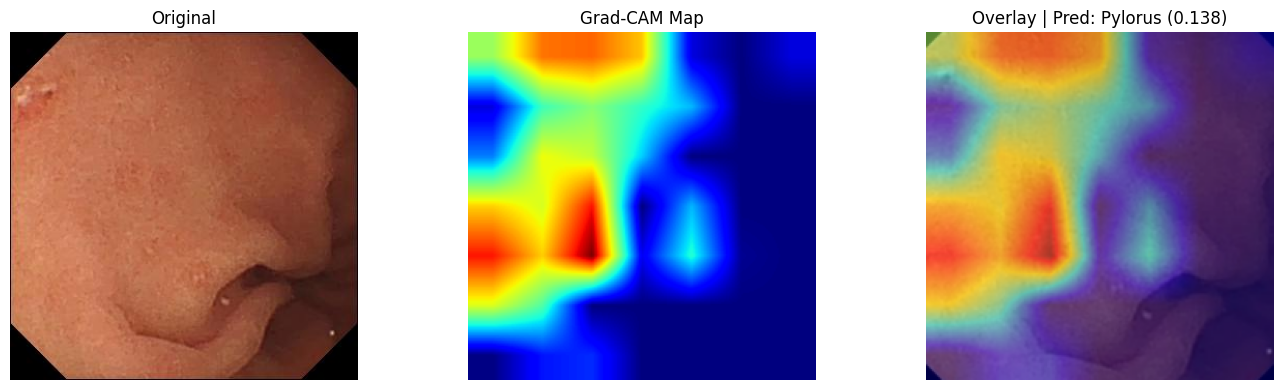

🩺 Prediction: Pylorus | Probability: 0.138


In [ ]:
from google.colab import files


convnext = get_base_convnext(model)
target_layer = convnext.stages[-1].blocks[-1]
cam = GradCAM(model=model, target_layers=[target_layer])


mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def to_rgb01(x_chw):
    x = x_chw.detach().cpu()
    x = x * std + mean
    x = torch.clamp(x, 0, 1)
    return x.permute(1,2,0).numpy()

print("Upload ONE image (jpg/png):")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print(" Using:", img_path)


pil = Image.open(img_path).convert("RGB")
x = val_transform(pil).unsqueeze(0).to(device)


with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0]
pred_idx = int(torch.argmax(probs).item())
pred_prob = float(probs[pred_idx].item())


grayscale_cam = cam(input_tensor=x)[0]
rgb01 = to_rgb01(x[0])
overlay = show_cam_on_image(rgb01, grayscale_cam, use_rgb=True)


plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.imshow(pil); plt.axis("off"); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(grayscale_cam, cmap="jet"); plt.axis("off"); plt.title("Grad-CAM Map")
plt.subplot(1,3,3); plt.imshow(overlay); plt.axis("off"); plt.title(f"Overlay | Pred: {class_names[pred_idx]} ({pred_prob:.3f})")
plt.tight_layout()
plt.show()

print(f" Prediction: {class_names[pred_idx]} | Probability: {pred_prob:.3f}")